# Student Dropout Risk Prediction
## Notebook 2 — Data Preprocessing & Feature Engineering

**Prerequisites:** Run `01_eda_dropout_prediction.ipynb` first.

### Objectives
- Load and clean the raw dataset
- Encode categorical features
- Engineer new risk-related features
- Handle class imbalance
- Split into train/test sets
- Save the processed data for model training

---
## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


> **Note:** This notebook uses `imbalanced-learn` for SMOTE. If you get an import error, install it:
> ```
> pip install imbalanced-learn
> ```

---
## 1. Load Dataset

In [2]:
dataset = fetch_ucirepo(id=697)
X_raw = dataset.data.features
y_raw = dataset.data.targets

df = pd.concat([X_raw, y_raw], axis=1)
df.columns = [col.strip() for col in df.columns]

print(f'Dataset loaded. Shape: {df.shape}')
df.head(3)

Dataset loaded. Shape: (4424, 37)


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout


---
## 2. Create Binary Target Variable

We convert the 3-class target (Dropout / Enrolled / Graduate) into a binary label:
- **1** = Dropout (at risk)
- **0** = Non-dropout (Enrolled or Graduate)

In [3]:
TARGET_COL = 'Target'

df['Dropout_Binary'] = (df[TARGET_COL] == 'Dropout').astype(int)

print('Target distribution (binary):')
print(df['Dropout_Binary'].value_counts().rename({0: 'Non-dropout', 1: 'Dropout'}))
print(f'\nDropout rate: {df["Dropout_Binary"].mean()*100:.1f}%')

Target distribution (binary):
Dropout_Binary
Non-dropout    3003
Dropout        1421
Name: count, dtype: int64

Dropout rate: 32.1%


---
## 3. Column Taxonomy

We group columns by type so we can apply the right transformations to each group.

In [4]:
# Columns to DROP (original target + any helper columns)
DROP_COLS = [TARGET_COL]

# Binary categorical columns (already 0/1 — no encoding needed)
BINARY_COLS = [
    'Gender',
    'Scholarship holder',
    'Debtor',
    'Tuition fees up to date',
    'Displaced',
    'Educational special needs',
    'International'
]

# Ordinal / nominal categorical columns (need encoding)
CATEGORICAL_COLS = [
    'Marital status',
    'Application mode',
    'Course',
    'Daytime/evening attendance\t',
    'Previous qualification',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Nacionality'
]

# Numerical continuous columns
NUMERICAL_COLS = [
    'Age at enrollment',
    'Previous qualification (grade)',
    'Admission grade',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

print('Column taxonomy defined.')
print(f'  Binary cols     : {len(BINARY_COLS)}')
print(f'  Categorical cols: {len(CATEGORICAL_COLS)}')
print(f'  Numerical cols  : {len(NUMERICAL_COLS)}')

Column taxonomy defined.
  Binary cols     : 7
  Categorical cols: 10
  Numerical cols  : 18


---
## 4. Handle Missing Values

In [5]:
print('Missing values before cleaning:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'None found — dataset is complete.')

# Fill any numerical NaNs with median (safe fallback)
for col in NUMERICAL_COLS:
    if col in df.columns and df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)
        print(f'  Filled {col} with median')

# Fill any categorical NaNs with mode
for col in CATEGORICAL_COLS:
    if col in df.columns and df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f'  Filled {col} with mode')

print('\nMissing values after cleaning:', df.isnull().sum().sum())

Missing values before cleaning:
None found — dataset is complete.

Missing values after cleaning: 0


---
## 5. Feature Engineering

We create new features that capture risk signals more directly than the raw columns.

In [6]:
# ── 5a. Academic performance features ────────────────────────────────────────

# Approval rate per semester (how many enrolled units the student passed)
df['Approval_Rate_Sem1'] = np.where(
    df['Curricular units 1st sem (enrolled)'] > 0,
    df['Curricular units 1st sem (approved)'] / df['Curricular units 1st sem (enrolled)'],
    0
)
df['Approval_Rate_Sem2'] = np.where(
    df['Curricular units 2nd sem (enrolled)'] > 0,
    df['Curricular units 2nd sem (approved)'] / df['Curricular units 2nd sem (enrolled)'],
    0
)

# Grade drop between semester 1 and 2 (negative = declining performance)
df['Grade_Drop'] = (
    df['Curricular units 1st sem (grade)'] - df['Curricular units 2nd sem (grade)']
)

# Total units failed across both semesters
df['Total_Units_Failed'] = (
    (df['Curricular units 1st sem (enrolled)'] - df['Curricular units 1st sem (approved)']) +
    (df['Curricular units 2nd sem (enrolled)'] - df['Curricular units 2nd sem (approved)'])
).clip(lower=0)

# Total units approved across both semesters
df['Total_Units_Approved'] = (
    df['Curricular units 1st sem (approved)'] +
    df['Curricular units 2nd sem (approved)']
)

# Average grade across both semesters (excluding 0-grade rows)
df['Avg_Grade'] = (
    df['Curricular units 1st sem (grade)'] + df['Curricular units 2nd sem (grade)'] 
) / 2

# Approval rate trend (sem2 - sem1): negative means worsening
df['Approval_Rate_Trend'] = df['Approval_Rate_Sem2'] - df['Approval_Rate_Sem1']

print('Academic features created.')

Academic features created.


In [7]:
# ── 5b. Financial risk features ───────────────────────────────────────────────

# Composite financial risk score (0 = no risk, 2 = maximum risk)
df['Financial_Risk_Score'] = (
    df['Debtor'].astype(int) +
    (1 - df['Tuition fees up to date'].astype(int))
)

# Scholarship but still in debt — high stress indicator
df['Scholarship_Debtor'] = (
    (df['Scholarship holder'] == 1) & (df['Debtor'] == 1)
).astype(int)

print('Financial features created.')

Financial features created.


In [8]:
# ── 5c. Engagement features ───────────────────────────────────────────────────

# Total evaluations across both semesters (proxy for engagement)
df['Total_Evaluations'] = (
    df['Curricular units 1st sem (evaluations)'] +
    df['Curricular units 2nd sem (evaluations)']
)

# Units enrolled in semester 2 vs semester 1 (dropping units = disengagement)
df['Enrollment_Drop'] = (
    df['Curricular units 1st sem (enrolled)'] - df['Curricular units 2nd sem (enrolled)']
)

print('Engagement features created.')

Engagement features created.


In [9]:
# ── 5d. Age risk flag ─────────────────────────────────────────────────────────

# Older students (25+) typically face more competing responsibilities
df['Mature_Student'] = (df['Age at enrollment'] >= 25).astype(int)

print('Age feature created.')

# Summary of all engineered features
ENGINEERED_COLS = [
    'Approval_Rate_Sem1', 'Approval_Rate_Sem2', 'Grade_Drop',
    'Total_Units_Failed', 'Total_Units_Approved', 'Avg_Grade',
    'Approval_Rate_Trend', 'Financial_Risk_Score', 'Scholarship_Debtor',
    'Total_Evaluations', 'Enrollment_Drop', 'Mature_Student'
]

print(f'\nTotal engineered features: {len(ENGINEERED_COLS)}')
df[ENGINEERED_COLS].describe().T[['mean', 'std', 'min', 'max']].round(3)

Age feature created.

Total engineered features: 12


,mean,std,min,max
Approval_Rate_Sem1,0.698,0.365,0.0,1.000
Approval_Rate_Sem2,0.660,0.383,0.0,1.000
Grade_Drop,0.411,2.890,-16.0,16.143
Total_Units_Failed,3.360,3.951,0.0,16.000
Total_Units_Approved,9.142,5.961,0.0,43.000
Avg_Grade,10.436,4.819,0.0,18.284
Approval_Rate_Trend,-0.038,0.189,-1.0,1.000
Financial_Risk_Score,0.233,0.539,0.0,2.000
Scholarship_Debtor,0.019,0.136,0.0,1.000
Total_Evaluations,16.362,7.665,0.0,72.000


---
## 6. Encode Categorical Features

In [10]:
# For XGBoost, we use label encoding for all categoricals.
# XGBoost handles label-encoded integers natively — no one-hot needed.

label_encoders = {}

for col in CATEGORICAL_COLS:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le
        print(f'  Encoded: {col} → {len(le.classes_)} unique values')

# Save encoders for use in the Streamlit app
joblib.dump(label_encoders, '../models/label_encoders.pkl')
print('\nLabel encoders saved to ../models/label_encoders.pkl')

  Encoded: Application mode → 18 unique values
  Encoded: Course → 17 unique values
  Encoded: Previous qualification → 17 unique values
  Encoded: Mother's qualification → 29 unique values
  Encoded: Father's qualification → 34 unique values
  Encoded: Mother's occupation → 32 unique values
  Encoded: Father's occupation → 46 unique values
  Encoded: Nacionality → 21 unique values

Label encoders saved to ../models/label_encoders.pkl


---
## 7. Assemble Final Feature Matrix

In [11]:
# Final feature set = original columns (encoded) + engineered features
ALL_FEATURES = BINARY_COLS + CATEGORICAL_COLS + NUMERICAL_COLS + ENGINEERED_COLS

# Keep only columns that exist in the dataframe
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]

X = df[ALL_FEATURES].copy()
y = df['Dropout_Binary'].copy()

print(f'Feature matrix shape : {X.shape}')
print(f'Target vector shape  : {y.shape}')
print(f'Total features       : {X.shape[1]}')
print(f'  Original features  : {len(BINARY_COLS + CATEGORICAL_COLS + NUMERICAL_COLS)}')
print(f'  Engineered features: {len(ENGINEERED_COLS)}')

Feature matrix shape : (4424, 45)
Target vector shape  : (4424,)
Total features       : 45
  Original features  : 35
  Engineered features: 12


In [12]:
# Check for any remaining NaN or infinite values
print('NaN values  :', X.isnull().sum().sum())
print('Inf values  :', np.isinf(X.values).sum())

# Replace any inf values with 0 (can happen in ratio calculations)
X.replace([np.inf, -np.inf], 0, inplace=True)
X.fillna(0, inplace=True)

print('After cleanup — NaN:', X.isnull().sum().sum(), '| Inf:', np.isinf(X.values).sum())

NaN values  : 0
Inf values  : 0
After cleanup — NaN: 0 | Inf: 0


---
## 8. Train / Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # ensures same dropout ratio in both splits
)

print('Train / test split (80/20 stratified):')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'  Dropout rate — train: {y_train.mean()*100:.1f}%')
print(f'  Dropout rate — test : {y_test.mean()*100:.1f}%')

Train / test split (80/20 stratified):
  X_train : (3539, 45)
  X_test  : (885, 45)
  Dropout rate — train: 32.1%
  Dropout rate — test : 32.1%


---
## 9. Handle Class Imbalance with SMOTE

SMOTE (Synthetic Minority Oversampling Technique) generates synthetic dropout samples so the model sees a balanced training set. We apply it **only to training data** — never to test data.

In [14]:
print('Before SMOTE:')
print(f'  Dropout (1)     : {y_train.sum()}')
print(f'  Non-dropout (0) : {(y_train == 0).sum()}')

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE:')
print(f'  Dropout (1)     : {y_train_bal.sum()}')
print(f'  Non-dropout (0) : {(y_train_bal == 0).sum()}')
print(f'  Total training samples: {len(X_train_bal)}')

Before SMOTE:
  Dropout (1)     : 1137
  Non-dropout (0) : 2402

After SMOTE:
  Dropout (1)     : 2402
  Non-dropout (0) : 2402
  Total training samples: 4804


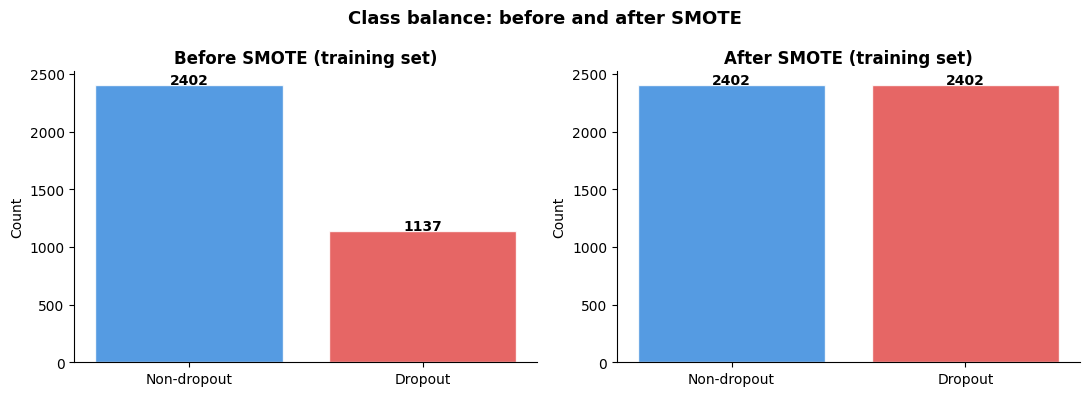

In [15]:
# Visualise class balance before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (counts, title) in zip(axes, [
    (y_train.value_counts(), 'Before SMOTE (training set)'),
    (pd.Series(y_train_bal).value_counts(), 'After SMOTE (training set)')
]):
    ax.bar(['Non-dropout', 'Dropout'], [counts[0], counts[1]],
           color=['#378ADD', '#E24B4A'], edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.suptitle('Class balance: before and after SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Feature Scaling

XGBoost is tree-based and doesn't require scaling — but we save a scaler anyway for use in the Streamlit app when displaying risk scores and for any future models we add.

In [16]:
scaler = StandardScaler()

# Fit only on training data — transform both
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrames (preserves column names for SHAP)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=ALL_FEATURES)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=ALL_FEATURES)

# Save scaler
joblib.dump(scaler, '../models/scaler.pkl')
print('Scaler saved to ../models/scaler.pkl')

Scaler saved to ../models/scaler.pkl


---
## 11. Save All Processed Data

In [17]:
# Save raw splits (unscaled — used for XGBoost which doesn't need scaling)
X_train_bal_df = pd.DataFrame(X_train_bal, columns=ALL_FEATURES)
X_train_bal_df.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)

pd.Series(y_train_bal, name='Dropout_Binary').to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

# Save scaled splits (for any future non-tree models)
X_train_scaled.to_csv('../data/processed/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test_scaled.csv', index=False)

# Save full feature list for reference in later notebooks
pd.Series(ALL_FEATURES).to_csv('../data/processed/feature_names.csv', index=False, header=False)

# Save the full processed dataframe (for Streamlit app)
df[ALL_FEATURES + ['Dropout_Binary', TARGET_COL]].to_csv(
    '../data/processed/full_processed.csv', index=False
)

print('All files saved to ../data/processed/')
print('\nSummary of saved files:')
for f in os.listdir('../data/processed/'):
    path = f'../data/processed/{f}'
    size = os.path.getsize(path) / 1024
    print(f'  {f:<35} {size:.1f} KB')

All files saved to ../data/processed/

Summary of saved files:
  feature_names.csv                   1.0 KB
  full_processed.csv                  750.1 KB
  smote_balance.png                   37.4 KB
  X_test.csv                          142.3 KB
  X_test_scaled.csv                   771.0 KB
  X_train.csv                         863.9 KB
  X_train_scaled.csv                  4190.3 KB
  y_test.csv                          2.6 KB
  y_train.csv                         14.1 KB


---
## 12. Preprocessing Summary

In [18]:
print('=' * 60)
print('  PREPROCESSING SUMMARY')
print('=' * 60)
print(f"""
Original dataset
  Rows            : {df.shape[0]}
  Raw features    : {len(BINARY_COLS + CATEGORICAL_COLS + NUMERICAL_COLS)}

After feature engineering
  Total features  : {len(ALL_FEATURES)}
  Engineered new  : {len(ENGINEERED_COLS)}

Train / test split (stratified 80/20)
  X_train (raw)   : {X_train.shape}
  X_test          : {X_test.shape}

After SMOTE (training set only)
  X_train_bal     : {X_train_bal_df.shape}
  Dropout samples : {y_train_bal.sum()}
  Non-dropout     : {(y_train_bal == 0).sum()}

Artifacts saved
  ../models/label_encoders.pkl
  ../models/scaler.pkl
  ../data/processed/X_train.csv
  ../data/processed/X_test.csv
  ../data/processed/y_train.csv
  ../data/processed/y_test.csv
  ../data/processed/feature_names.csv
  ../data/processed/full_processed.csv

Next step → Notebook 03: XGBoost model training
""")
print('=' * 60)

  PREPROCESSING SUMMARY

Original dataset
  Rows            : 4424
  Raw features    : 35

After feature engineering
  Total features  : 45
  Engineered new  : 12

Train / test split (stratified 80/20)
  X_train (raw)   : (3539, 45)
  X_test          : (885, 45)

After SMOTE (training set only)
  X_train_bal     : (4804, 45)
  Dropout samples : 2402
  Non-dropout     : 2402

Artifacts saved
  ../models/label_encoders.pkl
  ../models/scaler.pkl
  ../data/processed/X_train.csv
  ../data/processed/X_test.csv
  ../data/processed/y_train.csv
  ../data/processed/y_test.csv
  ../data/processed/feature_names.csv
  ../data/processed/full_processed.csv

Next step → Notebook 03: XGBoost model training

